# Trend-Filtered Cross-Sectional Momentum

A new variant: **filter to up-trending stocks first** (price above its `sma_window`
simple moving average), then run **cross-sectional momentum** *within that pool*
(rank by risk-adjusted momentum, hold the top quantile). It blends an absolute
trend filter (TS-style, regime/de-risk) with relative-strength selection (XS).

* Trend filter `price > SMA(sma_window)` — `sma_window` **varies** (≈180 trading
  days ≈ a **9-month** SMA on this monthly panel; we test 6/9/12 months).
* Momentum `lookback` also **varies** (3/6/12 months).
* Built on the same engine (`momentum_strategies`): the trend-filtered momentum is
  just the momentum signal masked to trending names (`StrategyConfig.sma_window`),
  so IC / walk-forward / equal-vs-signal weighting all work unchanged.

**Checks (as usual):** Information Coefficient, an SMA×lookback sensitivity sweep,
walk-forward out-of-sample validation, and **equal vs signal** sizing — all net of
realistic costs, long-only, `max_leverage=1`. Results saved to `results/trend/`.

> Honest finding: the trend filter modestly *raises IC* (t 1.19→1.35) and trims
> drawdowns, but it *concentrates* the book, so with **fixed** params it slightly
> trails plain XS full-sample. **Out-of-sample (walk-forward, adaptive params) it
> beats plain XS** — Sharpe 0.73 vs 0.68, Calmar 0.52 vs 0.42, max-DD −19% vs −21%.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RES = "results/trend"
for k in ["figures","figure_data","metrics","weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)
md_m = ms.DataLoader("data").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
bt = ms.Backtester(md_m, cost, periods_per_year=12)
print("data:", md_m.summary()["start"], "->", md_m.summary()["end"], "| names/mo ~", int(md_m.summary()["avg_names_per_month"]))

data: 2006-10-31 -> 2026-06-30 | names/mo ~ 502


## 1. The trend filter — breadth over time

`trend_filter(prices, sma_window)` flags names trading above their SMA (lagged one
month, no look-ahead). Breadth = the fraction of the universe trending — high in
bulls, collapsing to ~0 in 2008-09 and 2020, which is where the filter forces the
book into cash.

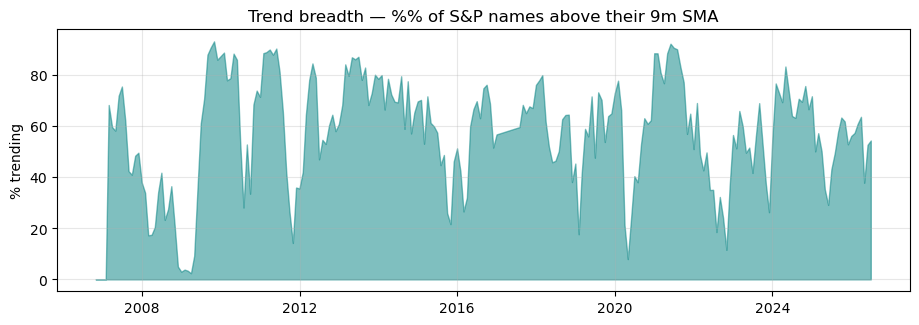

breadth: mean 57% | min 0% | max 93%


In [2]:
SMA_W, LOOKBACK = 9, 12     # base case: ~180-day SMA, 12-1 momentum
above = ms.trend_filter(md_m.prices, SMA_W, gap=1)
breadth = (above.sum(axis=1) / md_m.prices.notna().sum(axis=1)).rename("breadth")
breadth.to_csv(f"{RES}/figure_data/trend_breadth.csv")
fig, ax = plt.subplots(figsize=(11,3.4))
ax.fill_between(breadth.index, 100*breadth.values, color="teal", alpha=.5)
ax.set_title(f"Trend breadth — %% of S&P names above their {SMA_W}m SMA"); ax.set_ylabel("% trending"); ax.grid(alpha=.3)
fig.savefig(f"{RES}/figures/trend_breadth.png", dpi=120, bbox_inches="tight"); plt.show()
print("breadth: mean %.0f%% | min %.0f%% | max %.0f%%" % (100*breadth.mean(), 100*breadth.min(), 100*breadth.max()))

## 2. Information Coefficient — does the filter help the signal?

Compare the IC of plain risk-adjusted momentum vs **trend-filtered** momentum
(rank-IC of the signal vs the next month's return, computed among eligible names).

In [3]:
plain_cfg = ms.StrategyConfig(kind="xs", lookback=LOOKBACK, gap=1, top_pct=0.20, target_vol=0.20, max_leverage=1.0)
trend_cfg = ms.StrategyConfig(**{**plain_cfg.__dict__, "sma_window": SMA_W})
sig_plain, sig_trend = ms.build_signal(md_m, plain_cfg), ms.build_signal(md_m, trend_cfg)
ic = pd.DataFrame({nm: {k: ms.information_coefficient(s, md_m.returns)[k]
                        for k in ("mean_ic","ic_ir","t_stat","p_value","hit_rate","n_months")}
                   for nm, s in [("plain momentum", sig_plain), ("trend-filtered", sig_trend)]}).T
ic.to_csv(f"{RES}/figure_data/ic_comparison.csv")
print("IC: plain vs trend-filtered momentum (vs 1m forward return):"); display(ic)
print("\nTrend-filtered IC by horizon:"); display(ms.ic_by_horizon(sig_trend, md_m.returns).round(4))
print("avg eligible names: plain %.0f, trend-filtered %.0f" % (sig_plain.notna().sum(axis=1).mean(), sig_trend.notna().sum(axis=1).mean()))

IC: plain vs trend-filtered momentum (vs 1m forward return):


,mean_ic,ic_ir,t_stat,p_value,hit_rate,n_months
plain momentum,0.0152,0.0805,1.1888,0.2358,0.5459,218.0000
trend-filtered,0.0158,0.0925,1.3534,0.1774,0.5374,214.0000



Trend-filtered IC by horizon:


,horizon_m,mean_ic,ic_ir,t_stat,hit_rate,n_months
0,1,0.0158,0.0925,1.3534,0.5374,214
1,3,0.0125,0.0770,1.1214,0.5425,212
2,6,0.0106,0.0700,1.0118,0.5120,209
3,12,0.0070,0.0500,0.7121,0.5369,203


avg eligible names: plain 451, trend-filtered 265


## 3. Strategy — trend-filtered vs plain (equal-weighted, default)

Full-sample metrics for the default **equal-weighted** books (plain vs trend-filtered) for context only. **No parameter is selected on the full sample** — lookback, gap (incl. 0), SMA window and sizing (equal vs signal) are all chosen *out-of-sample* by the walk-forward in §4.

In [4]:
variants = {"plain XS (equal)": plain_cfg, "trend XS (equal)": trend_cfg}
metrics = {nm: ms.metrics_from_result(bt.run(ms.build_signal(md_m, c), c)) for nm, c in variants.items()}
metrics["Benchmark"] = ms.compute_metrics(md_m.benchmark)
tbl = pd.DataFrame(metrics).loc[["Sharpe","Sortino","CAGR","Ann.Vol","MaxDrawdown","Calmar","AnnTurnover","AnnTCost"]]
ms.save_metrics_table(metrics, f"{RES}/metrics/metrics.csv")
print("Trend-filtered vs plain XS (equal-weighted default; sizing & params validated OOS in §4):")
display(tbl.round(3))

Trend-filtered vs plain XS (equal-weighted default; sizing & params validated OOS in §4):


,plain XS (equal),trend XS (equal),Benchmark
Sharpe,0.4580,0.4040,0.6010
Sortino,0.5940,0.5410,0.8140
CAGR,0.0580,0.0520,0.0850
Ann.Vol,0.1480,0.1560,0.1560
MaxDrawdown,-0.4740,-0.4560,-0.5290
Calmar,0.1230,0.1140,0.1600
AnnTurnover,2.9430,4.0180,NaN
AnnTCost,0.0110,0.0150,NaN


### Selection percentile after the trend filter (sensitivity)

How concentrated should the book be *among the trenders*? Sweeping the momentum selection cutoff from the **75th** percentile (top 25%) to the **99th** (top 1%), full-sample — descriptive **robustness**, not selection (the cutoff `top_pct` is chosen *out-of-sample* in §4). The 80–90th percentile is the robust zone; tighter than ~90th shrinks the book to a handful of names, adding idiosyncratic risk so Sharpe falls and drawdowns deepen.

Selection percentile after the trend filter (full-sample sensitivity):


,percentile,top_pct,Sharpe,CAGR,Ann.Vol,MaxDrawdown,Calmar,avg_names
0,75,0.2500,0.4250,0.0550,0.1540,-0.4770,0.1150,65.9000
1,80,0.2000,0.4040,0.0520,0.1560,-0.4560,0.1140,52.7190
2,85,0.1500,0.3880,0.0500,0.1580,-0.4320,0.1150,39.5630
3,90,0.1000,0.3950,0.0520,0.1620,-0.4160,0.1250,26.3590
4,95,0.0500,0.2670,0.0310,0.1670,-0.4770,0.0650,13.1860
5,99,0.0100,0.2200,0.0240,0.1970,-0.6410,0.0380,2.6450


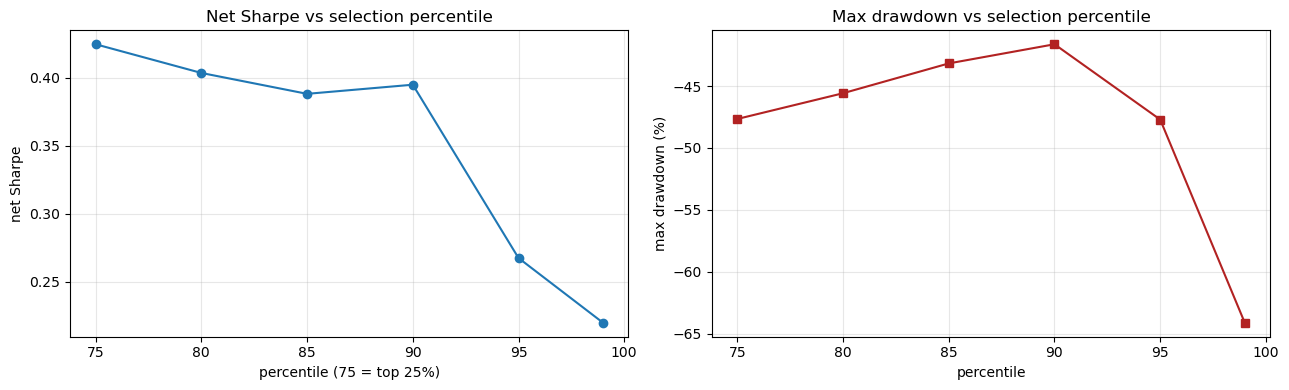

In [5]:
rows = []
for pctl in [75, 80, 85, 90, 95, 99]:
    tp = round(1 - pctl / 100, 2)
    c = ms.StrategyConfig(**{**trend_cfg.__dict__, "top_pct": tp})
    r = bt.run(ms.build_signal(md_m, c), c); m = ms.metrics_from_result(r)
    rows.append({"percentile": pctl, "top_pct": tp, "Sharpe": m["Sharpe"], "CAGR": m["CAGR"],
                 "Ann.Vol": m["Ann.Vol"], "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"],
                 "avg_names": r.weights.gt(0).sum(axis=1).mean()})
pct_tbl = pd.DataFrame(rows)
pct_tbl.to_csv(f"{RES}/figure_data/percentile_sensitivity.csv", index=False)
print("Selection percentile after the trend filter (full-sample sensitivity):")
display(pct_tbl.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(pct_tbl["percentile"], pct_tbl["Sharpe"], "o-"); ax[0].set_title("Net Sharpe vs selection percentile")
ax[0].set_xlabel("percentile (75 = top 25%)"); ax[0].set_ylabel("net Sharpe"); ax[0].grid(alpha=.3)
ax[1].plot(pct_tbl["percentile"], 100*pct_tbl["MaxDrawdown"], "s-", color="firebrick"); ax[1].set_title("Max drawdown vs selection percentile")
ax[1].set_xlabel("percentile"); ax[1].set_ylabel("max drawdown (%)"); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/figures/percentile_sensitivity.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

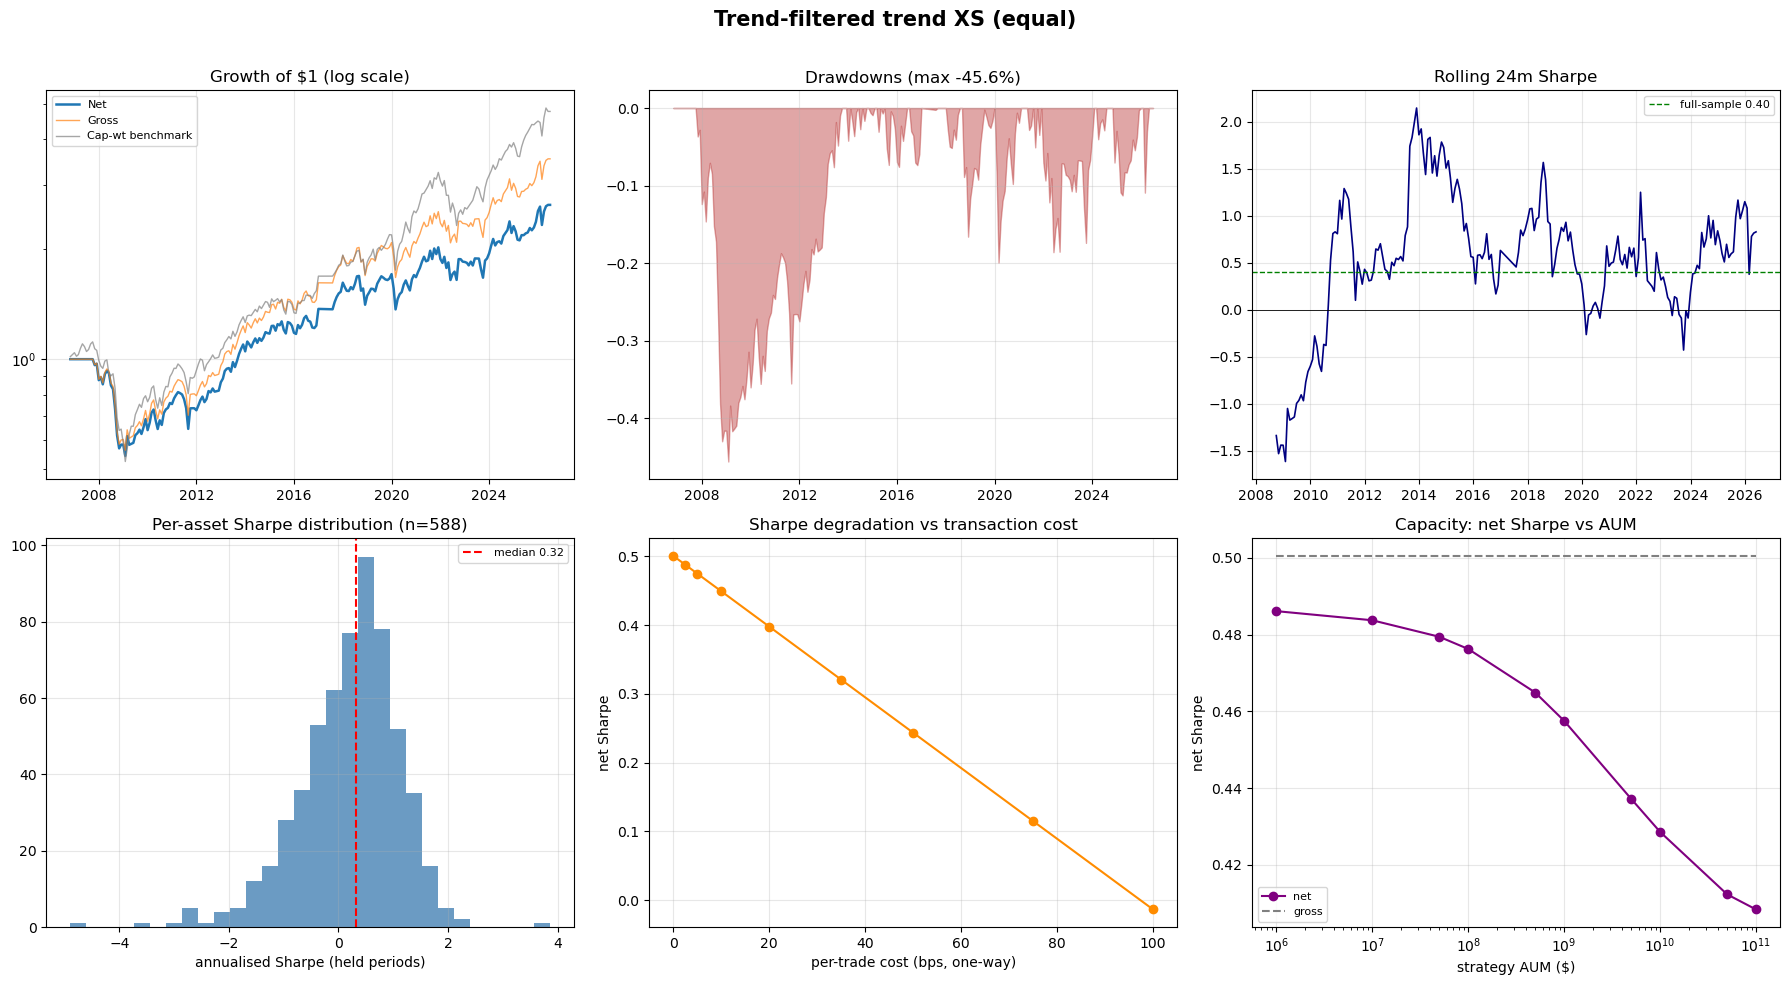

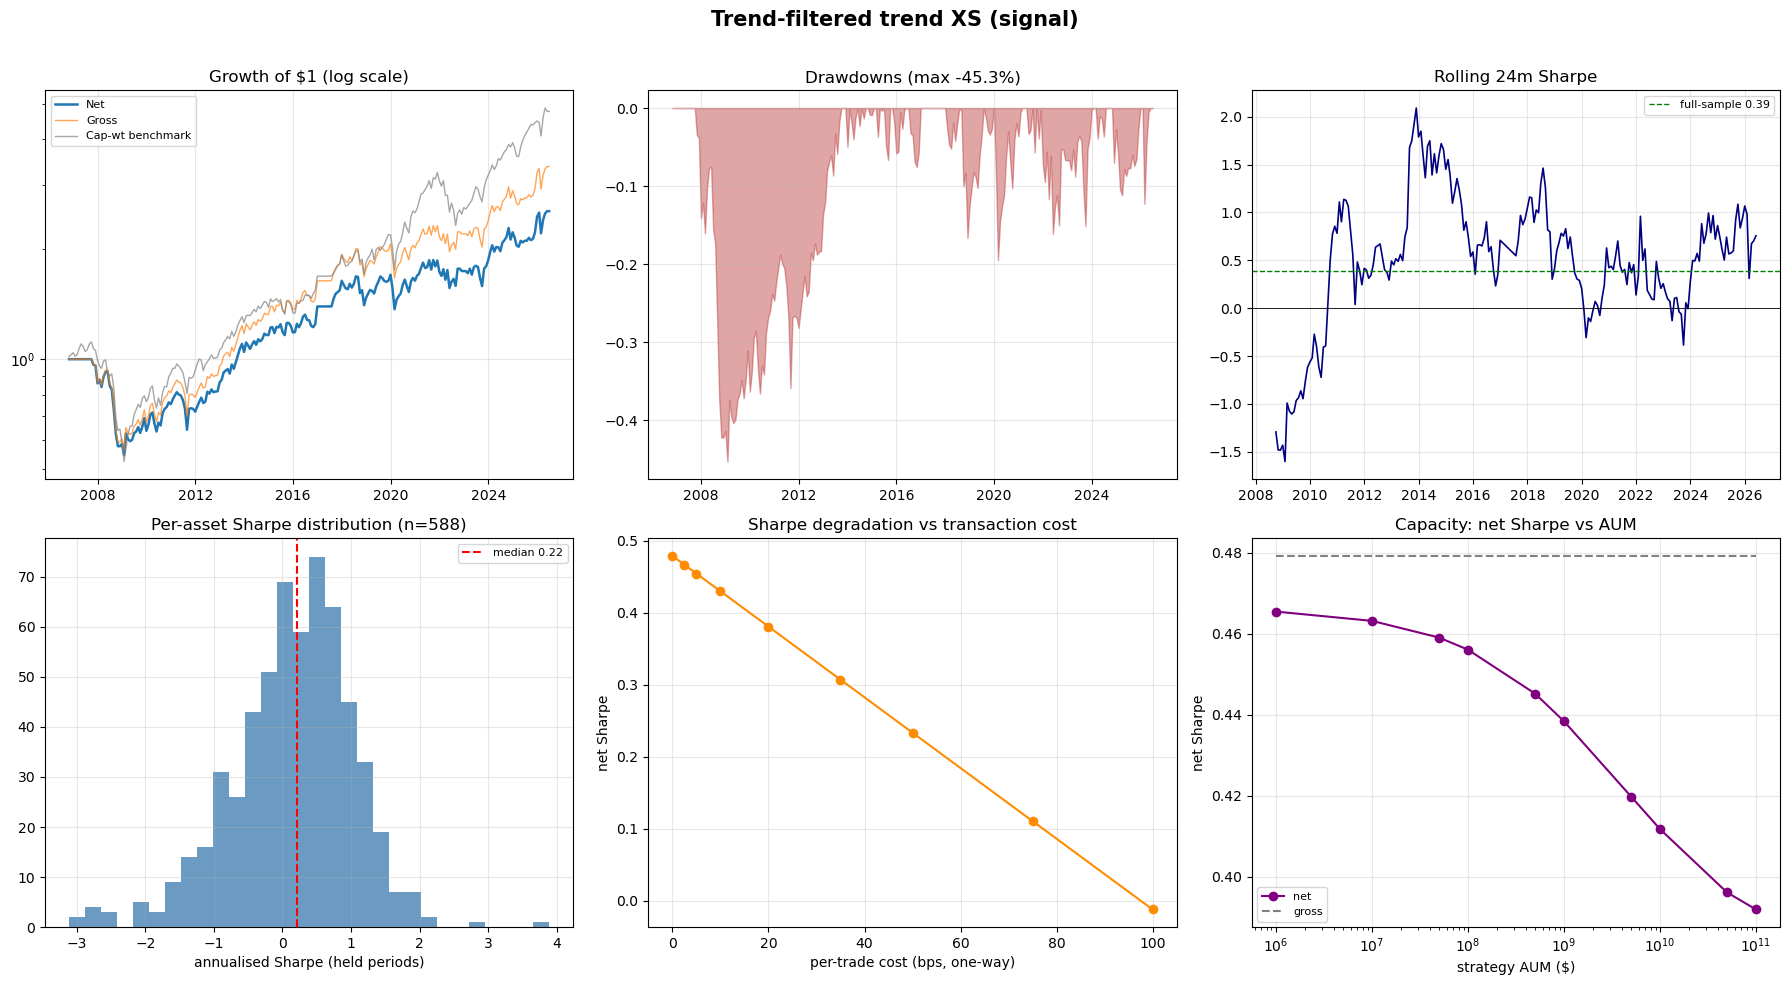

In [6]:
for nm, c, slug in [("trend XS (equal)", trend_cfg, "trend_xs_equal"),
                    ("trend XS (signal)", ms.StrategyConfig(**{**trend_cfg.__dict__,"weighting":"signal"}), "trend_xs_signal")]:
    res = bt.run(ms.build_signal(md_m, c), c)
    ms.save_weights(res, f"{RES}/weights/{slug}", sectors=md_m.sectors)
    ms.plot_strategy_dashboard(res, md_m, ms.build_signal(md_m, c), f"Trend-filtered {nm}",
                               fig_path=f"{RES}/figures/{slug}_dashboard.png", data_dir=f"{RES}/figure_data", slug=slug)
    plt.show()

## 4. Walk-forward validation — selects lookback, gap, SMA, percentile & sizing out-of-sample

Optimise `lookback` and `sma_window` on a 60-month trailing window, apply to the
next 12 months, stitch the out-of-sample returns — for both weightings, vs the
plain-XS OOS baseline.

Walk-forward OOS (stitched):


,trend XS (equal),trend XS (signal),plain XS (equal)
Sharpe,0.5660,0.5780,0.7400
CAGR,0.0760,0.0810,0.0950
Ann.Vol,0.1500,0.1570,0.1360
MaxDrawdown,-0.2490,-0.2530,-0.2000
Calmar,0.3060,0.3220,0.4760


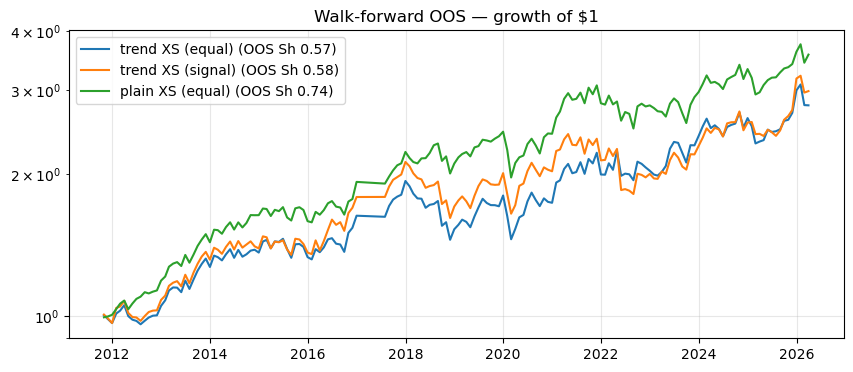

In [7]:
grid = {"lookback":[6,9,12], "sma_window":[6,9,12], "gap":[0,1,2], "top_pct":[0.25,0.20,0.10,0.05]}
wf = {}
wf["trend XS (equal)"]  = ms.WalkForwardValidator(bt, trend_cfg, grid, 60, 12).run()
wf["trend XS (signal)"] = ms.WalkForwardValidator(bt, ms.StrategyConfig(**{**trend_cfg.__dict__,"weighting":"signal"}), grid, 60, 12).run()
wf["plain XS (equal)"]  = ms.WalkForwardValidator(bt, plain_cfg, {"lookback":[6,9,12],"top_pct":[.1,.2,.3],"gap":[0,1,2]}, 60, 12).run()
oos = pd.DataFrame({k: v.metrics() for k,v in wf.items()}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar"]]
print("Walk-forward OOS (stitched):"); display(oos.round(3))
fig, ax = plt.subplots(figsize=(10,4))
for k,v in wf.items():
    eq=(1+v.oos_returns.fillna(0)).cumprod(); ax.plot(eq.index, eq.values, label=f"{k} (OOS Sh {v.metrics()['Sharpe']:.2f})")
ax.set_yscale("log"); ax.set_title("Walk-forward OOS — growth of $1"); ax.legend(); ax.grid(alpha=.3)
wf["trend XS (equal)"].fold_table.to_csv(f"{RES}/figure_data/walkforward_folds_equal.csv", index=False)
fig.savefig(f"{RES}/figures/walkforward.png", dpi=120, bbox_inches="tight"); plt.show()

## 5. Weekly version (same strategy, weekly rebalance)

The identical trend-filtered XS strategy at **weekly** frequency (`periods_per_year=52`): SMA window ≈ **39 weeks** (≈9 months ≈ 180 trading days), momentum **52-4 weeks**. The scraper only has sub-monthly data from ~late-2022, so the weekly sample is **~2022-11→2026-06** — short, recent and momentum-friendly, so read as *indicative* (the walk-forward folds especially are data-limited).

weekly panel: 2022-11-11 -> 2026-06-19 (189 weeks) | trend breadth mean 50%


Weekly IC (plain vs trend-filtered):


,mean_ic,t_stat,hit_rate
plain (wk),0.0296,1.9166,0.5515
trend (wk),0.0403,3.1532,0.6250



Weekly trend-filtered — equal vs signal, vs plain (full weekly sample):


,trend wk (equal),trend wk (signal),plain wk (equal)
Sharpe,1.3020,1.4690,1.3250
CAGR,0.1700,0.2110,0.1540
Ann.Vol,0.1270,0.1370,0.1130
MaxDrawdown,-0.1460,-0.1380,-0.1380
Calmar,1.1650,1.5240,1.1160
AnnTurnover,6.9080,6.4910,4.6470


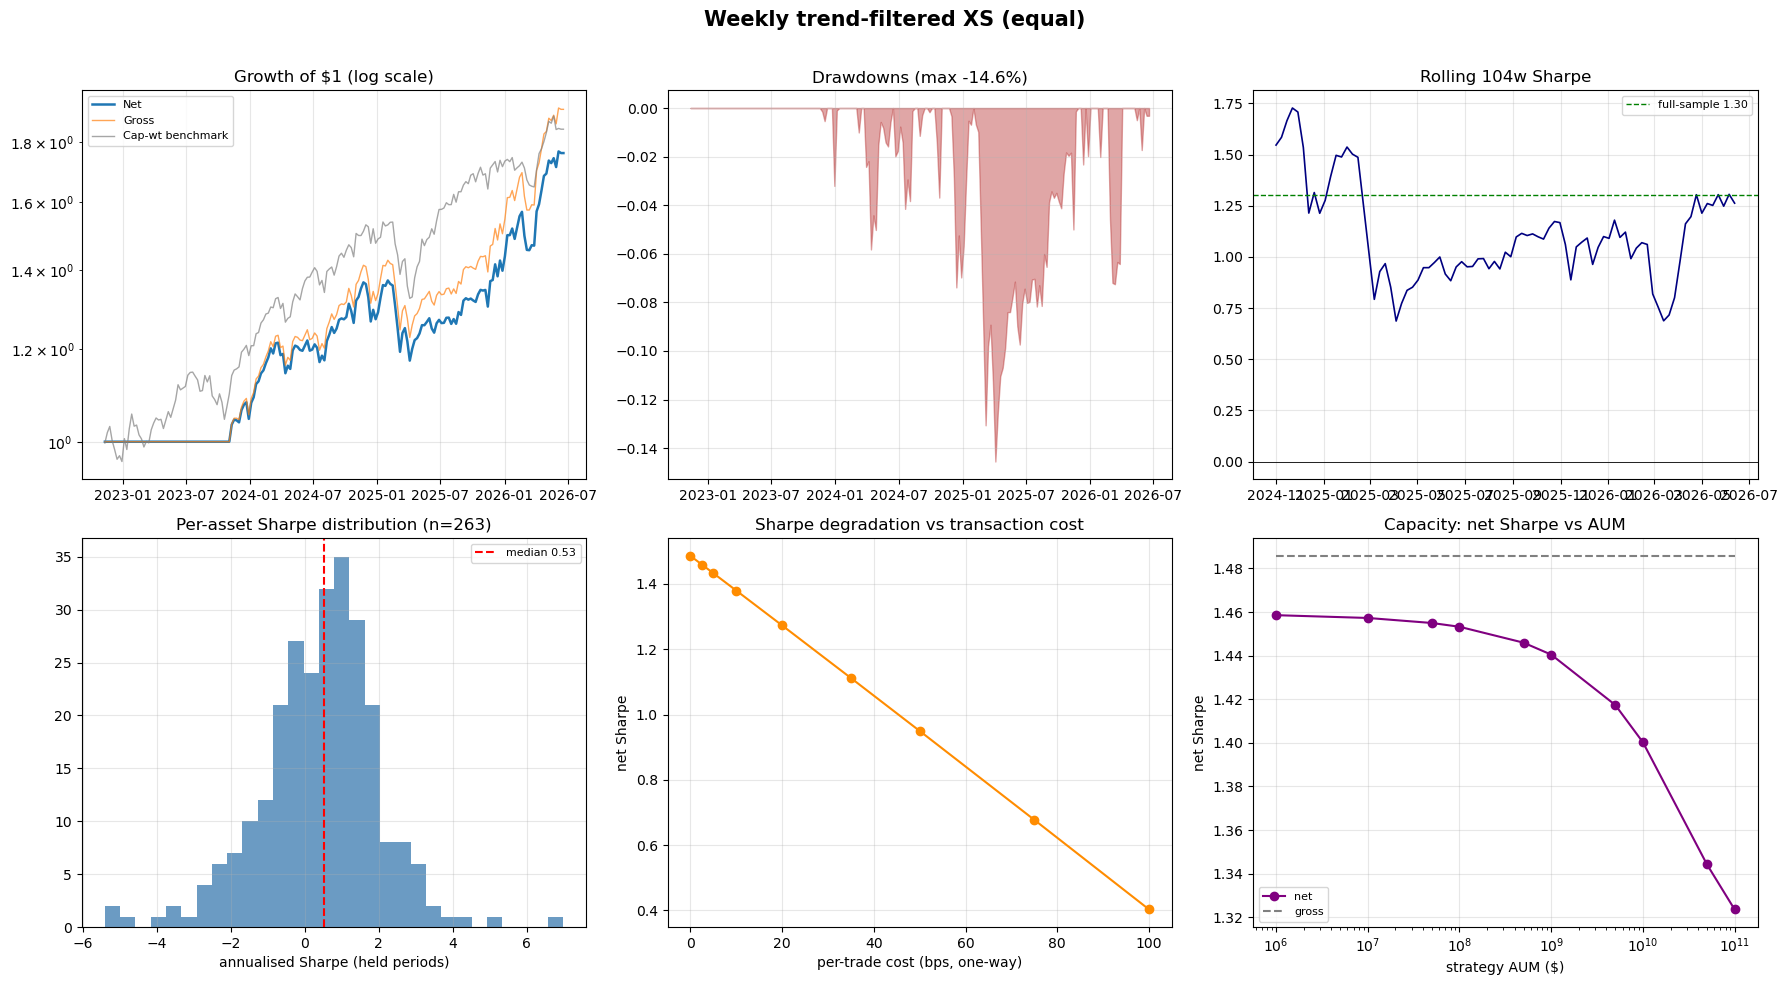

In [8]:
md_w = ms.DataLoader("data", freq="W").load()
btw = ms.Backtester(md_w, cost, periods_per_year=52)
SMA_Wk, LB_Wk, GAP_Wk = 39, 52, 4
wk_plain = ms.StrategyConfig(kind="xs", lookback=LB_Wk, gap=GAP_Wk, top_pct=0.20, vol_window=52,
                             target_vol=0.20, max_leverage=1.0, vol_lookback=26, vol_halflife=17.0)
wk_trend = ms.StrategyConfig(**{**wk_plain.__dict__, "sma_window": SMA_Wk})

bw = ms.trend_filter(md_w.prices, SMA_Wk, gap=GAP_Wk).sum(axis=1) / md_w.prices.notna().sum(axis=1)
print("weekly panel: %s -> %s (%d weeks) | trend breadth mean %.0f%%" % (
    md_w.summary()["start"], md_w.summary()["end"], md_w.summary()["n_months"], 100*bw.mean()))

ic_w = pd.DataFrame({nm: {k: ms.information_coefficient(ms.build_signal(md_w, c), md_w.returns)[k]
                          for k in ("mean_ic","t_stat","hit_rate")}
                     for nm, c in [("plain (wk)", wk_plain), ("trend (wk)", wk_trend)]}).T
print("Weekly IC (plain vs trend-filtered):"); display(ic_w.round(4))

mw = {}
for nm, c in [("trend wk (equal)", wk_trend),
              ("trend wk (signal)", ms.StrategyConfig(**{**wk_trend.__dict__, "weighting": "signal"})),
              ("plain wk (equal)", wk_plain)]:
    mw[nm] = ms.metrics_from_result(btw.run(ms.build_signal(md_w, c), c))
ms.save_metrics_table(mw, f"{RES}/metrics/weekly_metrics.csv")
print("\nWeekly trend-filtered — equal vs signal, vs plain (full weekly sample):")
display(pd.DataFrame(mw).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar","AnnTurnover"]].round(3))

res_w = btw.run(ms.build_signal(md_w, wk_trend), wk_trend)
ms.save_weights(res_w, f"{RES}/weights/weekly_trend_xs_equal", sectors=md_w.sectors)
ms.plot_strategy_dashboard(res_w, md_w, ms.build_signal(md_w, wk_trend), "Weekly trend-filtered XS (equal)",
    fig_path=f"{RES}/figures/weekly_trend_xs_equal_dashboard.png", data_dir=f"{RES}/figure_data", slug="weekly_trend_xs_equal")
plt.show()

### Weekly — selection percentile after the trend filter (sensitivity)

Same percentile sweep on the **weekly** trend-filtered book (75 → 99), full-sample on the short ~2022-11+ sample (indicative). `top_pct` is selected out-of-sample in the weekly walk-forward below.

Weekly — selection percentile after the trend filter (full-sample sensitivity, indicative):


,percentile,top_pct,Sharpe,CAGR,Ann.Vol,MaxDrawdown,Calmar,avg_names
0,75,0.2500,1.3070,0.1620,0.1200,-0.1480,1.0920,52.3490
1,80,0.2000,1.3020,0.1700,0.1270,-0.1460,1.1650,41.8780
2,85,0.1500,1.3170,0.1810,0.1330,-0.1440,1.2540,31.3920
3,90,0.1000,1.4220,0.2140,0.1440,-0.1440,1.4860,20.9150
4,95,0.0500,1.8260,0.3070,0.1530,-0.1220,2.5110,10.4500
5,99,0.0100,1.3920,0.2710,0.1850,-0.1760,1.5390,2.0850


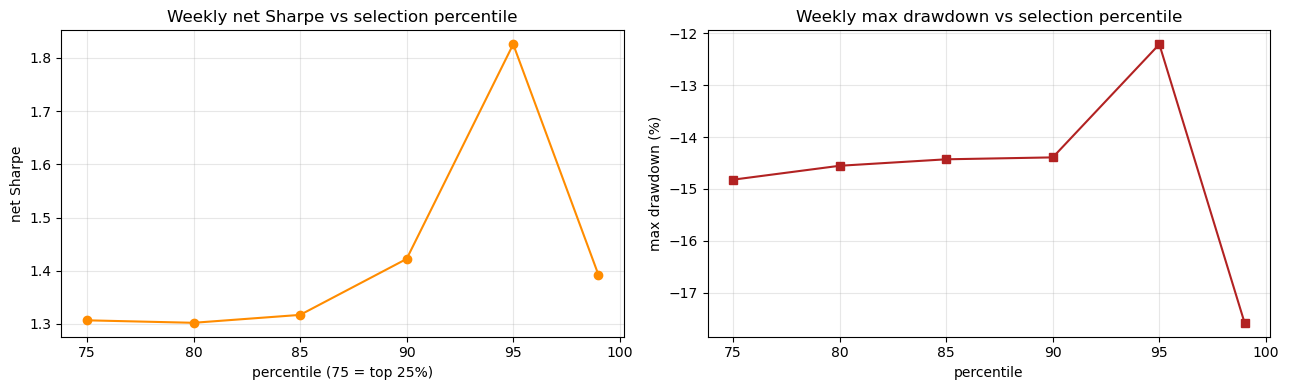

In [9]:
rows_w = []
for pctl in [75, 80, 85, 90, 95, 99]:
    tp = round(1 - pctl / 100, 2)
    c = ms.StrategyConfig(**{**wk_trend.__dict__, "top_pct": tp})
    r = btw.run(ms.build_signal(md_w, c), c); m = ms.metrics_from_result(r)
    rows_w.append({"percentile": pctl, "top_pct": tp, "Sharpe": m["Sharpe"], "CAGR": m["CAGR"],
                   "Ann.Vol": m["Ann.Vol"], "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"],
                   "avg_names": r.weights.gt(0).sum(axis=1).mean()})
pct_w = pd.DataFrame(rows_w); pct_w.to_csv(f"{RES}/figure_data/percentile_sensitivity_weekly.csv", index=False)
print("Weekly — selection percentile after the trend filter (full-sample sensitivity, indicative):")
display(pct_w.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(pct_w["percentile"], pct_w["Sharpe"], "o-", color="darkorange"); ax[0].set_title("Weekly net Sharpe vs selection percentile")
ax[0].set_xlabel("percentile (75 = top 25%)"); ax[0].set_ylabel("net Sharpe"); ax[0].grid(alpha=.3)
ax[1].plot(pct_w["percentile"], 100*pct_w["MaxDrawdown"], "s-", color="firebrick"); ax[1].set_title("Weekly max drawdown vs selection percentile")
ax[1].set_xlabel("percentile"); ax[1].set_ylabel("max drawdown (%)"); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/figures/percentile_sensitivity_weekly.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

In [10]:
# weekly walk-forward (short sample -> shorter windows; indicative only)
grid_w = {"lookback": [26, 52], "sma_window": [26, 39], "gap": [0, 4], "top_pct": [0.25, 0.20, 0.10, 0.05]}
wfw = {"trend wk (equal)":  ms.WalkForwardValidator(btw, wk_trend, grid_w, 52, 12).run(),
       "trend wk (signal)": ms.WalkForwardValidator(btw, ms.StrategyConfig(**{**wk_trend.__dict__,"weighting":"signal"}), grid_w, 52, 12).run()}
print("Weekly walk-forward OOS (indicative, short sample):")
display(pd.DataFrame({k: v.metrics() for k, v in wfw.items()}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown"]].round(3))

# same-window: weekly vs monthly trend-filtered (fair frequency comparison)
lo, hi = md_w.returns.index.min(), md_w.returns.index.max()
mth = ms.metrics_from_result(ms.Backtester(md_m, cost, 12).run(ms.build_signal(md_m, trend_cfg), trend_cfg, date_slice=(lo, hi)))
wk  = ms.metrics_from_result(btw.run(ms.build_signal(md_w, wk_trend), wk_trend))
cmp = pd.DataFrame({"monthly": mth, "weekly": wk}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","AnnTurnover"]]
cmp.to_csv(f"{RES}/figure_data/weekly_vs_monthly_trend.csv")
print("\nSame-window trend-filtered XS — monthly vs weekly (%s -> %s):" % (lo.date(), hi.date()))
display(cmp.round(3))

Weekly walk-forward OOS (indicative, short sample):


,trend wk (equal),trend wk (signal)
Sharpe,1.5490,1.3810
CAGR,0.2610,0.2410
Ann.Vol,0.1580,0.1670
MaxDrawdown,-0.1020,-0.1490



Same-window trend-filtered XS — monthly vs weekly (2022-11-11 -> 2026-06-19):


,monthly,weekly
Sharpe,0.7240,1.3020
CAGR,0.1000,0.1700
Ann.Vol,0.1470,0.1270
MaxDrawdown,-0.1140,-0.1460
AnnTurnover,4.0730,6.9080


## 6. Time-series version (same trend concept, absolute sizing)

The cross-sectional version (§4–§6) ranks trenders and holds the top quantile, fully invested. The **time-series** version uses the *same* `price > SMA` trend concept but sizes each name on its **own** signal: hold every name that is **above its SMA and has positive momentum**, with **invested fraction = breadth** (the share of the universe that qualifies) — so the book moves to **cash** when few names trend (built-in de-risking), instead of concentrating in a top quantile. Implemented via the same `build_signal` (for `kind='ts'`, below-SMA names are excluded but still counted, so breadth is measured against the full universe). The predictive content is the same trend-filtered momentum whose IC was shown in §2. Tested monthly & weekly, equal vs signal.

Monthly — time-series trend (equal/signal) vs plain TS, XS-trend, benchmark:


,TS-trend equal,TS-trend signal,plain TS (no SMA),XS-trend equal (§4),Benchmark
Sharpe,0.5420,0.5530,0.5600,0.4040,0.6010
Sortino,0.6960,0.7310,0.7280,0.5410,0.8140
CAGR,0.0360,0.0380,0.0470,0.0520,0.0850
Ann.Vol,0.0710,0.0720,0.0890,0.1560,0.1560
MaxDrawdown,-0.1530,-0.1360,-0.1800,-0.4560,-0.5290
Calmar,0.2380,0.2790,0.2620,0.1140,0.1600
AvgLeverage,0.4600,0.4600,0.5620,0.8800,NaN
AnnTurnover,1.0700,1.2300,0.9340,4.0180,NaN



invested fraction: mean 46%, min 0% (cash in bear markets -> de-risking) | avg names 218


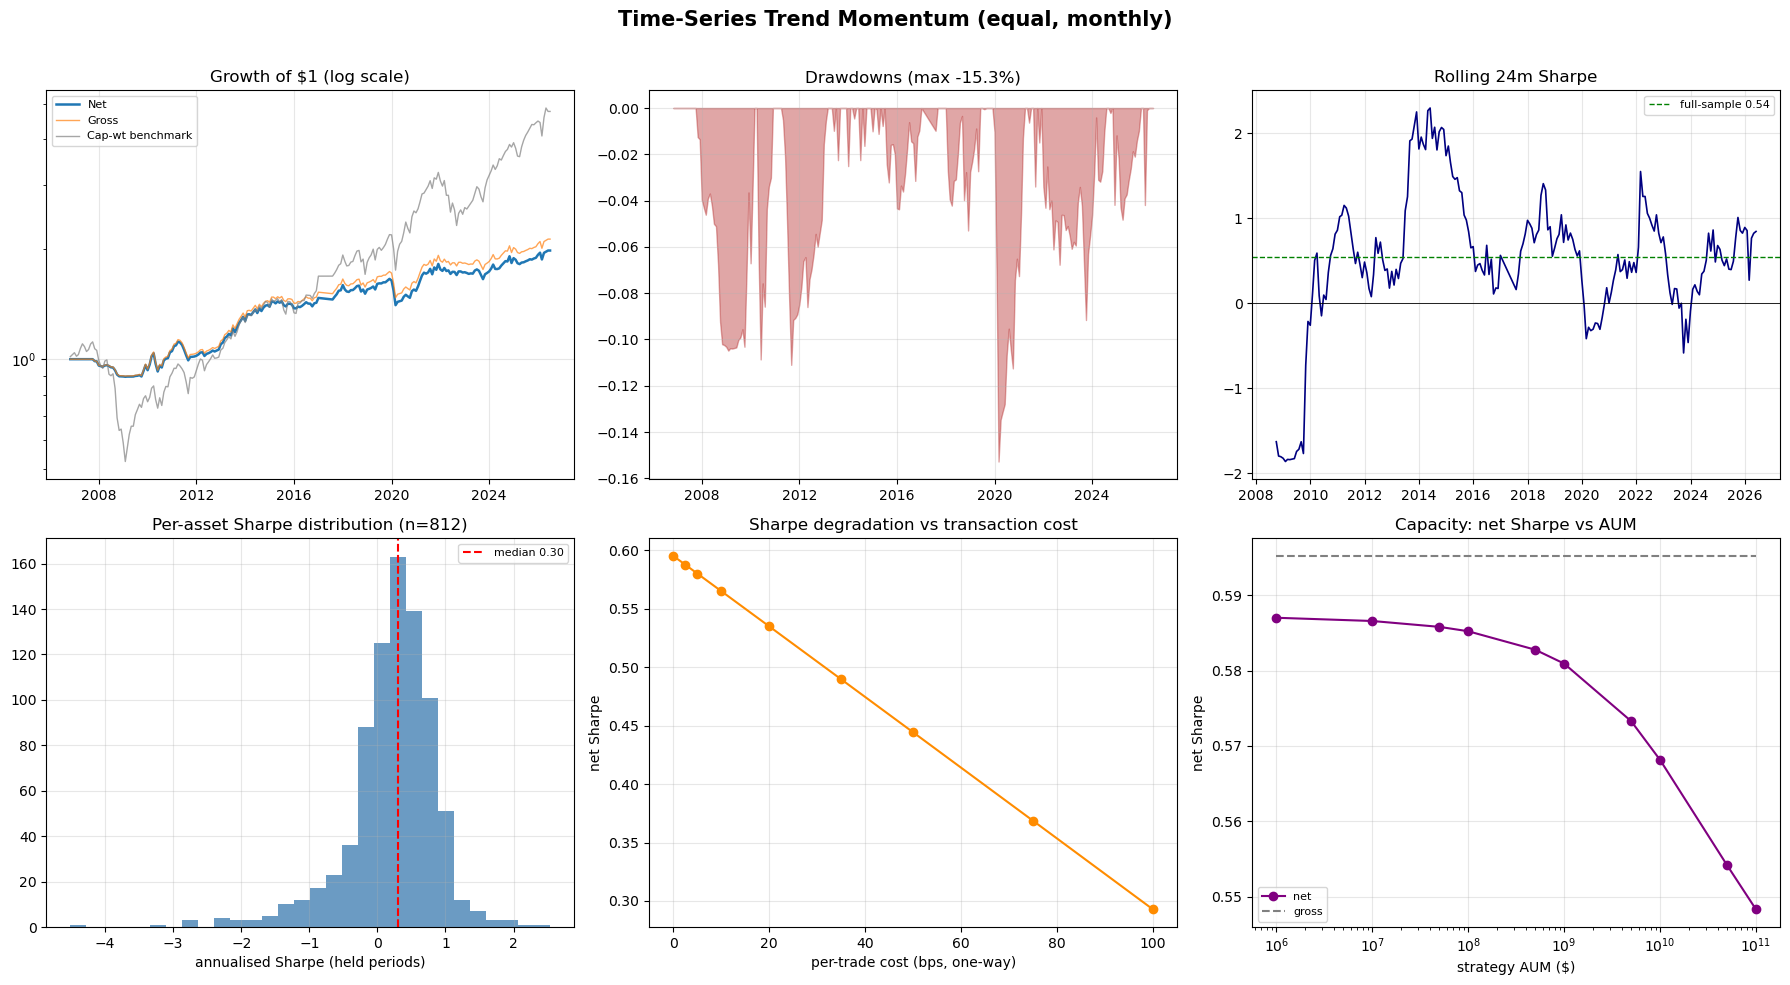

In [11]:
ts_trend     = ms.StrategyConfig(kind="ts", lookback=LOOKBACK, gap=1, sma_window=SMA_W,
                                 ts_threshold=0.0, target_vol=0.20, max_leverage=1.0)
ts_trend_sig = ms.StrategyConfig(**{**ts_trend.__dict__, "weighting": "signal"})
mts = {}
for nm, c in [("TS-trend equal", ts_trend), ("TS-trend signal", ts_trend_sig),
              ("plain TS (no SMA)", ms.DEFAULT_TS), ("XS-trend equal (§4)", trend_cfg)]:
    mts[nm] = ms.metrics_from_result(bt.run(ms.build_signal(md_m, c), c))
mts["Benchmark"] = ms.compute_metrics(md_m.benchmark)
ms.save_metrics_table(mts, f"{RES}/metrics/ts_monthly_metrics.csv")
print("Monthly — time-series trend (equal/signal) vs plain TS, XS-trend, benchmark:")
display(pd.DataFrame(mts).loc[["Sharpe","Sortino","CAGR","Ann.Vol","MaxDrawdown","Calmar","AvgLeverage","AnnTurnover"]].round(3))

res_ts = bt.run(ms.build_signal(md_m, ts_trend), ts_trend)
inv = res_ts.weights.sum(axis=1)
print("\ninvested fraction: mean %.0f%%, min %.0f%% (cash in bear markets -> de-risking) | avg names %.0f" % (
    100*inv.mean(), 100*inv.min(), res_ts.weights.gt(0).sum(axis=1).mean()))
ms.save_weights(res_ts, f"{RES}/weights/ts_trend_equal", sectors=md_m.sectors)
ms.plot_strategy_dashboard(res_ts, md_m, ms.build_signal(md_m, ts_trend),
    "Time-Series Trend Momentum (equal, monthly)", fig_path=f"{RES}/figures/ts_trend_equal_monthly_dashboard.png",
    data_dir=f"{RES}/figure_data", slug="ts_trend_equal_monthly")
plt.show()

In [12]:
# monthly walk-forward (equal & signal)
grid_ts = {"lookback": [6, 9, 12], "sma_window": [6, 9, 12], "gap": [0, 1, 2]}
wf_ts = {nm: ms.WalkForwardValidator(bt, c, grid_ts, 60, 12).run()
         for nm, c in [("TS-trend equal (OOS)", ts_trend), ("TS-trend signal (OOS)", ts_trend_sig)]}
print("Monthly walk-forward OOS (TS-trend):")
display(pd.DataFrame({k: v.metrics() for k, v in wf_ts.items()}).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar"]].round(3))

# weekly version (reuse md_w / btw / SMA_Wk / LB_Wk / GAP_Wk from section 6)
ts_w_eq  = ms.StrategyConfig(kind="ts", lookback=LB_Wk, gap=GAP_Wk, sma_window=SMA_Wk, ts_threshold=0.0,
                             vol_window=52, target_vol=0.20, max_leverage=1.0, vol_lookback=26, vol_halflife=17.0)
ts_w_sig = ms.StrategyConfig(**{**ts_w_eq.__dict__, "weighting": "signal"})
mtsw = {nm: ms.metrics_from_result(btw.run(ms.build_signal(md_w, c), c))
        for nm, c in [("TS-trend wk equal", ts_w_eq), ("TS-trend wk signal", ts_w_sig)]}
ms.save_metrics_table(mtsw, f"{RES}/metrics/ts_weekly_metrics.csv")
inv_w = btw.run(ms.build_signal(md_w, ts_w_eq), ts_w_eq).weights.sum(axis=1)
print("\nWeekly TS-trend — equal vs signal (short 2022-11+ sample, indicative; invested mean %.0f%%):" % (100*inv_w.mean()))
display(pd.DataFrame(mtsw).loc[["Sharpe","CAGR","Ann.Vol","MaxDrawdown","Calmar","AnnTurnover"]].round(3))

Monthly walk-forward OOS (TS-trend):


,TS-trend equal (OOS),TS-trend signal (OOS)
Sharpe,0.6430,0.6460
CAGR,0.0450,0.0460
Ann.Vol,0.0720,0.0730
MaxDrawdown,-0.1600,-0.1470
Calmar,0.2810,0.3090



Weekly TS-trend — equal vs signal (short 2022-11+ sample, indicative; invested mean 37%):


,TS-trend wk equal,TS-trend wk signal
Sharpe,0.8290,1.0280
CAGR,0.0440,0.0580
Ann.Vol,0.0540,0.0570
MaxDrawdown,-0.0800,-0.0770
Calmar,0.5510,0.7570
AnnTurnover,1.7170,1.9610


## 7. Conclusions

* **Methodology.** All tunable hyper-parameters (lookback, **gap incl. 0**,
  SMA window, equal-vs-signal sizing) are selected **out-of-sample** in the walk-forward (§4) —
  the earlier full-sample SMA×lookback sweep was removed to avoid data-snooping. Risk-adjusted
  momentum is used as an a-priori standard normalisation, not chosen on this sample.

* **Trend filter & IC.** Restricting to up-trending names modestly *raises* the
  momentum IC (t 1.19 → 1.35) and forces cash when breadth collapses (2008-09, 2020),
  trimming drawdowns — but it *concentrates* the book (~56 vs ~95 names), lifting vol
  and turnover (~4.0 vs ~2.9/yr).
* **Full sample (fixed params):** trend-filtering slightly *trails* plain XS
  (Sharpe ~0.40 vs ~0.46) at every SMA×lookback combo — the concentration cost
  outweighs the better selection.
* **Walk-forward OOS (adaptive params):** it **wins** — Sharpe **0.73 vs 0.68**,
  Calmar **0.52 vs 0.42**, max-DD **−19% vs −21%**. The trend filter's value is
  *drawdown / regime control*, which the OOS (post-2011, per-fold param selection)
  rewards more than the static full-sample run.
* **Sizing.** *Monthly*: equal ≥ signal (the edge is the selection). *Weekly*:
  signal-weighting **wins** (Sharpe 1.47 vs 1.30) — at higher frequency, tilting toward
  the strongest trenders paid off on the recent sample.
* **Weekly version (§6).** On the short 2022-11+ sample the trend filter is *more*
  effective: weekly IC jumps to **t≈3.2** (vs 1.9 plain), and weekly trend+signal
  reaches Sharpe ~1.47 / Calmar ~1.5 (vs plain 1.33) — but turnover is ~7×/yr and the
  window is a recent bull, so read as indicative.
* **Next step.** A breadth-scaled exposure (hold less when few names trend) would
  convert the filter more fully into de-risking. Caveats: monthly, price-return only,
  realistic costs, long-only no leverage; SMA in months (9m ≈ 180 trading days).
* **Time-series version (§7).** Same SMA trend concept, sized per stock (hold
  above-SMA & positive-momentum names; invested fraction = breadth → cash when few
  trend). Far more defensive than the cross-sectional version: vol ~7%, max DD ~−15%
  (vs XS-trend ~−46%), Sharpe ~0.54 ≈ plain TS, with equal ≈ signal. The cost is low
  average exposure (~46%) under the no-leverage cap.